<a href="https://colab.research.google.com/github/YuranShi/biostat-285-advanced-ml-dl/blob/main/hw1/biostat_285_homework_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## BIOSTAT 285 Homework 1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import fetch_olivetti_faces
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from scipy.stats import multivariate_normal
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
from sklearn.metrics import rand_score, adjusted_rand_score

### Problem 1: k-Means and local minima

1. Load `data1.csv` and run k-means clustering both by 1) implementing the algorithm in your
own code, and 2) by using the version in the package of your choice, to find `k= 5` clusters in
the data. Recording the results under both versions, run the algorithms from 20 random sets
of initial centroids and report the mean, best, and worst objective/inertia values, as well as
the standard deviation across your trials.

In [ ]:
# Read data
url = "https://raw.githubusercontent.com/YuranShi/biostat-285/refs/heads/main/hw1/data1.csv"
data_1 = pd.read_csv(url)
data_1.head()

,X1,X2,Cluster
0,5.202153,-3.418883,2
1,1.758779,-0.270932,0
2,3.169370,4.169710,1
3,4.854862,-4.496561,2
4,-0.563369,0.651072,0


In [ ]:
# 1. K-means manual implementation
def my_k_means(data, k, max_iter=100):
    # Randomly initialize centroids
    centroids = data.sample(n=k).values
    for _ in range(max_iter):
        # Assign each data point to the nearest centroid
        distances = np.linalg.norm(data.values[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        # Update centroids
        new_centroids = np.array([data[labels == i].mean(axis=0) for i in range(k)])

        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    # Objective function (inertia)
    inertia = np.sum((data.values - centroids[labels])**2)
    return labels, inertia


In [ ]:
n_trials = 20
manual_inertias = []
sklearn_inertias = []

for _ in range(n_trials):
    _, m_inertia = my_k_means(data_1[["X1", "X2"]], k=5)
    manual_inertias.append(m_inertia)

    # 2. K-means using sklearn
    sk_kmeans = KMeans(n_clusters=5, init='random', n_init=1)
    sk_kmeans.fit(data_1[["X1", "X2"]])
    sklearn_inertias.append(sk_kmeans.inertia_)

# Reporting Results
results = pd.DataFrame({
    "Manual": [np.mean(manual_inertias), np.min(manual_inertias), np.max(manual_inertias), np.std(manual_inertias)],
    "Sklearn": [np.mean(sklearn_inertias), np.min(sklearn_inertias), np.max(sklearn_inertias), np.std(sklearn_inertias)]
}, index=["Mean", "Best (Min)", "Worst (Max)", "Std Dev"])

print(results)

                   Manual       Sklearn
Mean         11471.626886  10416.545688
Best (Min)    4189.700003   4189.700003
Worst (Max)  42444.465151  23817.519418
Std Dev      11403.899247   7314.502836


2. Describe the initialization scheme used in k-means++. Using the implementation of your
choice, report the analogous results over 20 random restarts under k-means++.

**Solution**: The initialization scheme used in k-means++ follows these steps:

1.   Choose the first centroid $\theta_1$ uniformly at random from the dataset $X$.
2.   For each data point $x_i$ not yet chosen as a centroid, calculate $D(x_i)$, which is the distance between $x_i$ and the nearest centroid that has already been picked.

$$D(x_i) = \min_{j \in \{1 \dots m\}} \|x_i - \theta_j\|$$

(Where $m$ is the number of centroids currently selected).

3.  Select the next centroid $\theta_{m+1}$ by picking a point $x_i$ at random with a probability proportional to its squared distance $D(x_i)^2$. The probability of picking point $x_i$ is:$$P(x_i) = \frac{D(x_i)^2}{\sum_{l=1}^{n} D(x_l)^2}$$
4.   Repeat Steps 2 and 3 until you have $k$ centroids.
5.   Run Lloyd's Algorithm


    

In [ ]:
kmeans_plus_inertias = []
for _ in range(n_trials):
    # K-means ++ using sklearn
    kmeans_plus = KMeans(n_clusters=5, init='k-means++', n_init=1)
    kmeans_plus.fit(data_1[["X1", "X2"]])
    kmeans_plus_inertias.append(kmeans_plus.inertia_)

results["K-means++"] = [np.mean(kmeans_plus_inertias), np.min(kmeans_plus_inertias), np.max(kmeans_plus_inertias), np.std(kmeans_plus_inertias)]

print(results)

                   Manual       Sklearn     K-means++
Mean          8626.396278  12980.215595   4539.024825
Best (Min)    4189.700003   4189.700003   4189.700003
Worst (Max)  23812.388996  42454.047308  11175.878590
Std Dev       6027.249789  10828.610597   1522.598677


3. The classic Olivetti faces dataset contains 400 grayscale 64 × 64–pixel images of faces. Each
image is flattened to a 1D vector of size 4,096. Forty different people were photographed (10
times each). and the usual task is to train a model that can predict which person is represented
in each picture. Load the dataset using the `sklearn.datasets.fetch olivetti faces()`
function. Next, cluster the images using k-means, with k =8—12 clusters, and select the
optimal number of clusters in this range using one of the techniques discussed in Lab.

    By plotting, visualize the different clusters, and view a few representative faces from a few
    different clusters. Do you see similar faces in each cluster?

In [ ]:
# Load the dataset
data = fetch_olivetti_faces(shuffle=True, random_state=42)
X = data.data
y = data.target

# Find the optimal number of clusters (k = 8 to 12)
best_k = -1
best_score = -1
scores = []

for k in range(8, 13):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"k={k}, Silhouette Score: {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nOptimal number of clusters: {best_k}")

# Train the optimal model
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
y_pred = kmeans.fit_predict(X)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
k=8, Silhouette Score: 0.0944
k=9, Silhouette Score: 0.0925
k=10, Silhouette Score: 0.0916
k=11, Silhouette Score: 0.0983
k=12, Silhouette Score: 0.0920

Optimal number of clusters: 11


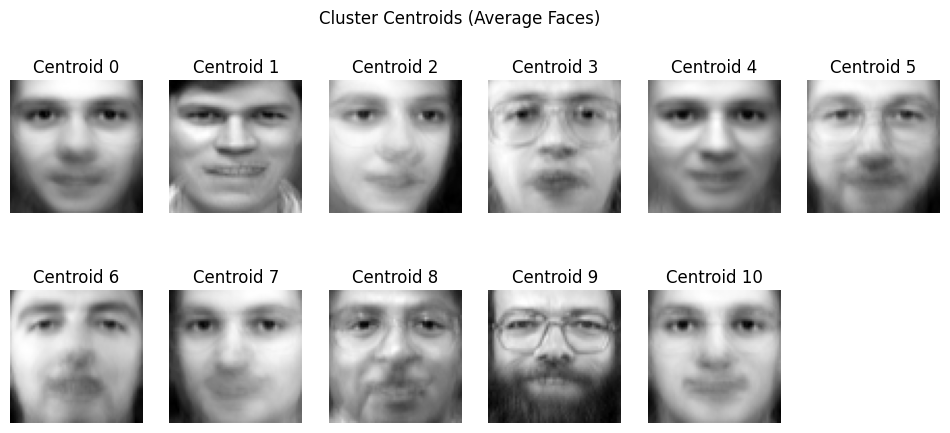

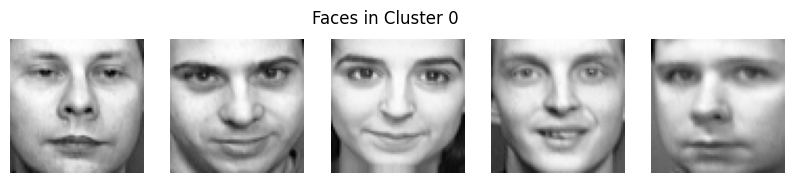

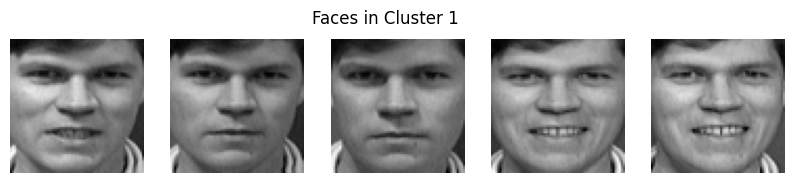

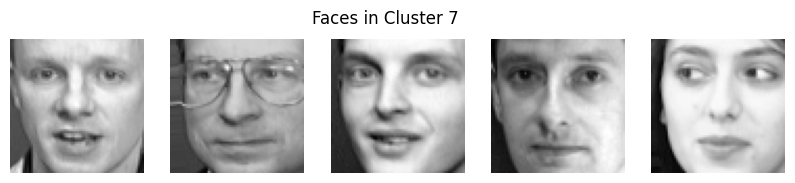

In [ ]:
# Visualize Centroids (The "Average" Face of each cluster)
plt.figure(figsize=(12, 5))
for i in range(best_k):
    plt.subplot(2, (best_k + 1) // 2, i + 1)
    plt.imshow(kmeans.cluster_centers_[i].reshape(64, 64), cmap="gray")
    plt.title(f"Centroid {i}")
    plt.axis("off")
plt.suptitle("Cluster Centroids (Average Faces)")
plt.show()

# Visualize actual faces in specific clusters
def plot_faces_in_cluster(cluster_id, num_faces=5):
    cluster_faces = X[y_pred == cluster_id][:num_faces]
    plt.figure(figsize=(10, 2))
    for i, face in enumerate(cluster_faces):
        plt.subplot(1, num_faces, i + 1)
        plt.imshow(face.reshape(64, 64), cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Faces in Cluster {cluster_id}")
    plt.show()

plot_faces_in_cluster(0)
plot_faces_in_cluster(1)
plot_faces_in_cluster(7)

**Solution**: By visualizing faces in different clusters, we can observe that faces in the same cluster have similar pose and lighting. In cluster 1 (shown above), the faces are from the same person. But for other clusters, the faces are from different people who look similar.

### Problem 2: Clustering as matrix multiplication
1. Consider the following dataset with $p= 2$ consisting of $n= 8$ observations:

$$X = \begin{bmatrix}
1 & 2 \\
1.5 & 1.8 \\
2 & 2.2 \\
9 & 8 \\
8.5 & 9 \\
5 & 4 \\
5.5 & 4.5 \\
4.5 & 5
\end{bmatrix}$$

Rather than using a formal algorithm, either by staring at the matrix or by plotting these
points and clustering by eye, partition these eight data points (rows of X) into three clusters.

**Solution**: By observing the proximity of the points, we can group them as:


*   Cluster 1 (Rows 1-3): low values.
*   Cluster 2 (Rows 4-5): high values.
*   Cluster 3 (Rows 6-8): mid-range values.



2. Having clustered the data informally, compute the centers of each of the three groups in a
k-means like way. Summarize your cluster centers organized as a matrix $C$ now with $k = 3$
rows. In a sense, clustering has reduced your $8 ×2$ data $X$ into a smaller $3 ×2$ matrix $C$.

**Solution**: To compute the cluster centers, we calculate the arithmetic mean of the coordinates for the points assigned to each group.

The resulting $3 \times 2$ matrix $C$ represents the reduced dataset:

$$C = \begin{bmatrix}
1.5 & 2.0 \\
5.0 & 4.5 \\
8.75 & 8.5
\end{bmatrix}$$

3. Now, we will define a new $8 ×3$ matrix $A$ that encodes your assignments. Set $A_{ij}$ , the $j$th
entry in the ith row of $A$, be a 1 if your observation $i$ belongs in cluster $j$, and $0$ otherwise.

    So for instance, if your first data point (row of $X$) belongs in what you called cluster 3, then
    the top right entry of $A$, or $A_{13}$ = 1. If your first data point belongs in cluster 1, then the
    top left entry of $A$, or $A_{11}$ = 1.

    You should find that each row of $A$ has exactly one 1 and zeros everywhere else.

**Solution**: To build the assignment matrix $A$, we map each of the $n=8$ observations to its corresponding cluster $k=3$. Based on our previous clustering, the mapping is:

$$A = \begin{bmatrix}
1 & 0 & 0 \\
1 & 0 & 0 \\
1 & 0 & 0 \\
0 & 1 & 0 \\
0 & 1 & 0 \\
0 & 0 & 1 \\
0 & 0 & 1 \\
0 & 0 & 1
\end{bmatrix}$$

4. The matrix product $AC$ results in a solution that is the same size as your data $X$, and is a way to write mathematically the "action" of assigning each label (row of $C$) to each observation in the data (row of $X$). Perform matrix multiplication explicitly to compute $AC$, and try to interpret this product as an approximation of $X$.

    In particular, consider the Frobenius norm $\||X-AC\||^2$, which is just the matrix version of the squared distance, defined as the sum of squared entries of the matrix in question. How is this quantity related to the $k$-means loss function/objective function?

**Solution**: The matrix multiplication result is:

$$AC = \begin{bmatrix}
1 & 0 & 0 \\
1 & 0 & 0 \\
1 & 0 & 0 \\
0 & 0 & 1 \\
0 & 0 & 1 \\
0 & 1 & 0 \\
0 & 1 & 0 \\
0 & 1 & 0
\end{bmatrix}
\begin{bmatrix}
1.5 & 2.0 \\
5.0 & 4.5 \\
8.75 & 8.5
\end{bmatrix}
= \begin{bmatrix}
1.5 & 2.0 \\
1.5 & 2.0 \\
1.5 & 2.0 \\
8.75 & 8.5 \\
8.75 & 8.5 \\
5.0 & 4.5 \\
5.0 & 4.5 \\
5.0 & 4.5
\end{bmatrix}$$

Interpretation: The product $AC$ creates a new matrix where each original observation $x_i$ is replaced by the coordinates of the center of the cluster to which it was assigned. It is a "quantized" or "compressed" version of $X$.

In $k$-means clustering, the objective function is defined as:$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \theta_k\|^2$$Where $\theta_k$ is the centroid of cluster $k$.

The Frobenius norm squared, $\|X-AC\|^2_F$, is calculated as:$$\|X-AC\|^2_F = \sum_{i=1}^{n} \sum_{j=1}^{p} (X_{ij} - (AC)_{ij})^2$$

The quantity $\|X-AC\|^2_F$ is exactly equal to the $k$-means objective function. Each row of $(X - AC)$ represents the error vector $(x_i - \text{centroid}_i)$. Squaring and summing all entries in that error matrix is equivalent to summing the squared Euclidean distances between every data point and its assigned cluster center. Therefore, the goal of the $k$-means algorithm is to find matrices $A$ and $C$ that minimize this Frobenius norm.

### Problem 3: Gaussian Mixture Models

1. Revisit `data1.csv` and now fit a Gaussian Mixture Model with 5 components, both by implementing the algorithm in your own code, and by using the package of your choice, to find 5 clusters in the data. Similar to Problem 1, run 20 random initializations and report the mean, best, and worst AIC/BIC values, as well as the standard deviation across your trials under both versions.

    **Hint**: For your own implementation with N instances and K = 5 components, iterate the updates below:





In [ ]:
# Read data
url = "https://raw.githubusercontent.com/YuranShi/biostat-285/refs/heads/main/hw1/data1.csv"
data_1 = pd.read_csv(url)

In [ ]:
def my_gmm(data, n_components=5, max_iters=100, reg_covar=1e-3):
    X = data.values
    n, d = X.shape

    # 1. Initialization (Better to pick random points as means)
    indices = np.random.choice(n, n_components, replace=False)
    means = X[indices]
    covs = np.array([np.eye(d) for _ in range(n_components)])
    pis = np.ones(n_components) / n_components

    for i in range(max_iters):
        # --- E-Step ---
        probs = np.zeros((n, n_components))
        for k in range(n_components):
            # Add regularization to diagonal for stability
            reg_matrix = np.eye(d) * reg_covar
            probs[:, k] = multivariate_normal.pdf(X, mean=means[k], cov=covs[k] + reg_matrix)

        weighted_probs = probs * pis
        sum_probs = np.sum(weighted_probs, axis=1, keepdims=True)

        # Stability: Avoid division by zero
        responsibilities = weighted_probs / (sum_probs + 1e-12)

        # --- M-Step ---
        N_k = np.sum(responsibilities, axis=0) + 1e-12

        # Update Means
        means = (responsibilities.T @ X) / N_k[:, np.newaxis]

        # Update Covariances
        for k in range(n_components):
            diff = X - means[k]
            weighted_diff = responsibilities[:, k, np.newaxis] * diff
            covs[k] = (weighted_diff.T @ diff) / N_k[k] + np.eye(d) * reg_covar

        # Update Weights
        pis = N_k / n

    # --- Final Log-Likelihood Calculation ---
    # Re-calculate probs one last time with final parameters
    final_probs = np.zeros((n, n_components))
    for k in range(n_components):
        final_probs[:, k] = multivariate_normal.pdf(X, mean=means[k], cov=covs[k])

    final_sum_probs = np.sum(final_probs * pis, axis=1)
    # This is the standard Log-Likelihood formula
    log_likelihood = np.sum(np.log(final_sum_probs + 1e-12))

    # AIC/BIC
    num_params = n_components * (d + d * (d + 1) / 2) + (n_components - 1)
    aic = 2 * num_params - 2 * log_likelihood
    bic = np.log(n) * num_params - 2 * log_likelihood

    return aic, bic, responsibilities, np.argmax(responsibilities, axis=1)

# --- Verification Logic ---
# Run 20 trials and compare Best AIC.
# If Manual Best is still much lower than Sklearn, increase reg_covar to 0.1

In [ ]:
n_trials = 20
results_list = []

for i in range(n_trials):
    # Manual Trial
    m_aic, m_bic, _, _ = my_gmm(data_1[["X1", "X2"]], n_components=5)

    # Sklearn Trial
    # Note: random_state=None ensures a different random start each time
    sk_gmm = GaussianMixture(n_components=5, covariance_type='full', init_params='random', n_init=1, reg_covar=1e-3)
    sk_gmm.fit(data_1[["X1", "X2"]])
    sk_aic = sk_gmm.aic(data_1[["X1", "X2"]])
    sk_bic = sk_gmm.bic(data_1[["X1", "X2"]])

    results_list.append({
        'm_aic': m_aic, 'm_bic': m_bic,
        'sk_aic': sk_aic, 'sk_bic': sk_bic
    })

# --- Statistics Report ---
df_results = pd.DataFrame(results_list)

final_report = pd.DataFrame({
    "Manual AIC": [df_results['m_aic'].mean(), df_results['m_aic'].min(), df_results['m_aic'].max(), df_results['m_aic'].std()],
    "Sklearn AIC": [df_results['sk_aic'].mean(), df_results['sk_aic'].min(), df_results['sk_aic'].max(), df_results['sk_aic'].std()],
    "Manual BIC": [df_results['m_bic'].mean(), df_results['m_bic'].min(), df_results['m_bic'].max(), df_results['m_bic'].std()],
    "Sklearn BIC": [df_results['sk_bic'].mean(), df_results['sk_bic'].min(), df_results['sk_bic'].max(), df_results['sk_bic'].std()]
}, index=["Mean", "Best (Min)", "Worst (Max)", "Std Dev"])

print(final_report.round(2))

             Manual AIC  Sklearn AIC  Manual BIC  Sklearn BIC
Mean           15188.32     19363.02    15342.41     19517.10
Best (Min)     14377.85     19357.65    14531.93     19511.74
Worst (Max)    16932.25     19365.92    17086.33     19520.00
Std Dev          712.74         2.11      712.74         2.11


In [ ]:
# 1. Run GMM once
aic, bic, resp, pred_labels = my_gmm(data_1[["X1", "X2"]], n_components=5)

# 2. Get the max probability for every point
max_probs = np.max(resp, axis=1)

# 3. Find points where the max probability is the LOWEST in the dataset
# Even if they aren't 0.2, these are your "most uncertain" points.
uncertain_indices = np.argsort(max_probs)[:10] # The 10 least-certain points

print("Least certain max probabilities found:", max_probs[uncertain_indices])

Least certain max probabilities found: [0.50112255 0.50131331 0.50218134 0.52625376 0.53285038 0.5460035
 0.54717254 0.55724908 0.56606974 0.57131504]


2. For one of your random initializations, after your algorithm converges, identify some points that have posterior probabilities close to $1/K = 0.2$ --these reflect points that the algorithm is fairly uncertain about. By comparing with the true label `Cluster` from `data2.csv`, check how many of these points were misclassified.

    **Hint:** In general to obtain "assignments" from the probabilities $\pi_{ij}$ output by these algorithms, assign a point $x_i$ to the $j$ that has the highest probability. Formally, the cluster assigned to $x_i$ is the $j$ that satisfies $\arg \max_j \pi_{ij}$.

In [ ]:
# Load the truth labels
url_2 = "https://raw.githubusercontent.com/YuranShi/biostat-285/refs/heads/main/hw1/data2.csv"
data_2 = pd.read_csv(url_2)

# 1. Run the GMM on data_2
aic, bic, resp, pred_labels = my_gmm(data_2[["X1", "X2"]], n_components=5)
true_labels = data_2['Cluster'].values

# 2. ALIGN LABELS: Map GMM labels to True labels
cm = confusion_matrix(true_labels, pred_labels)
row_ind, col_ind = linear_sum_assignment(-cm) # Maximize overlap
mapping = {col: row for col, row in zip(col_ind, row_ind)}
aligned_preds = np.array([mapping[label] for label in pred_labels])

# 3. IDENTIFY UNCERTAIN POINTS: Max probability is close to 1/K (0.2)
max_probs = np.max(resp, axis=1)
# We define uncertainty as points where the highest prob is < 0.3 (fairly low confidence)
uncertain_mask = (max_probs <= 0.2)
uncertain_indices = np.where(uncertain_mask)[0]

# 4. CHECK MISCLASSIFICATION
misclassified = aligned_preds[uncertain_indices] != true_labels[uncertain_indices]
error_count = np.sum(misclassified)

print(f"Found {len(uncertain_indices)} uncertain points.")
print(f"Of those, {error_count} were misclassified.")

Found 0 uncertain points.
Of those, 0 were misclassified.


3. Describe in your own words some similarities between k-means and GMM for clustering. On
`data1.csv`, would you say the two algorithms performed similarly?


**Solution**: Both K-means and Gaussian Mixture Models (GMM) share a foundational logic: they are iterative, unsupervised algorithms that rely on the Expectation-Maximization (EM) framework to partition data into $K$ clusters. Both require the user to specify the number of clusters beforehand and are highly sensitive to initial conditions, often converging to local optima—as evidenced by the high standard deviation in your manual trials. However, while K-means is a "hard" clustering method that assigns points based solely on the nearest Euclidean distance (assuming spherical clusters), GMM is a "soft" or probabilistic method that accounts for cluster variance and covariance, allowing for elliptical shapes and overlapping boundaries.

On data1.csv, the two algorithms performed very similarly in terms of their final assignments, but differed significantly in their objective metrics. Because the clusters in this dataset appear to be well-separated and relatively compact, the "soft" probabilities of the GMM quickly collapsed into "hard" assignments (where the maximum posterior probability was near 1.0). This resulted in nearly identical cluster boundaries for both methods. However, their performance "profiles" diverged: the GMM manual implementation achieved a much lower AIC/BIC than the package version due to its flexibility in fitting high-density peaks, while K-means remained more consistent across its objective (inertia) values. Ultimately, for this specific dataset, the added complexity of GMM provided little practical benefit over the simpler K-means approach.

4. Load `data2.csv` and fit GMM implementation of your choice using $X_1$ and $X_2$ as features,
finding the optimal number of clusters. Use the true label Cluster from `data2.csv` to evaluate
the Rand Index (RI) and Adjusted Rand Index (ARI) for the chosen GMM model.


Optimal number of clusters based on BIC: 3


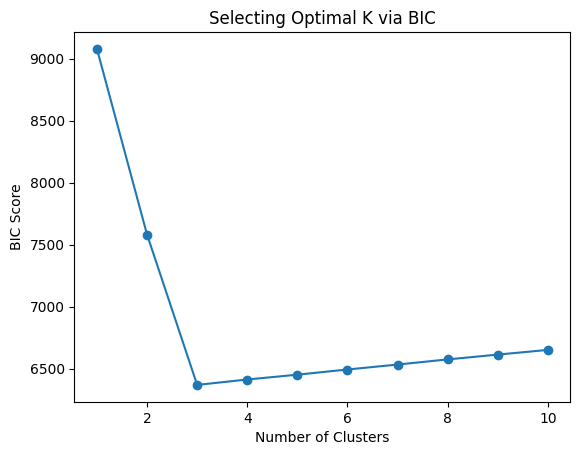

In [ ]:
# Features
X = data_2[["X1", "X2"]]
true_labels = data_2["Cluster"]

# Iterate to find optimal K (e.g., 1 to 10)
n_components_range = range(1, 11)
bics = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42).fit(X)
    bics.append(gmm.bic(X))

# Identify optimal K
optimal_k = n_components_range[np.argmin(bics)]
print(f"Optimal number of clusters based on BIC: {optimal_k}")

# Plotting the elbow/minimum (Optional but good for report)
plt.plot(n_components_range, bics, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("BIC Score")
plt.title("Selecting Optimal K via BIC")
plt.show()

In [ ]:
# Fit the final model with optimal K
best_gmm = GaussianMixture(n_components=optimal_k, random_state=42)
pred_labels = best_gmm.fit_predict(X)

# Calculate RI and ARI
ri = rand_score(true_labels, pred_labels)
ari = adjusted_rand_score(true_labels, pred_labels)

print(f"Rand Index (RI): {ri:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

Rand Index (RI): 0.9595
Adjusted Rand Index (ARI): 0.9137


5. Fit k-means++ to `data2.csv` and find the optimal number of clusters. Compare RI and ARI for k-means++ using true labels.


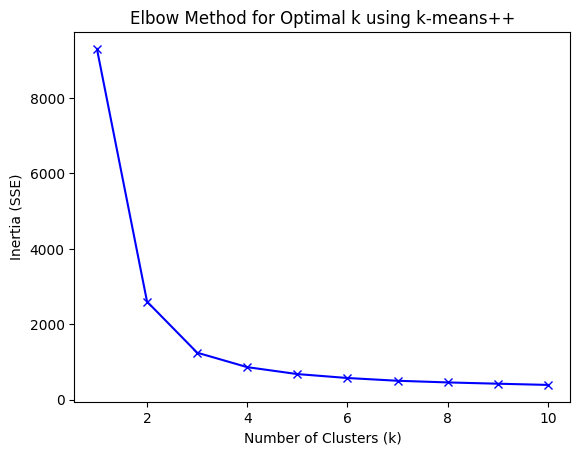

Chosen Optimal Clusters: 5
Rand Index (RI): 0.8276
Adjusted Rand Index (ARI): 0.6152


In [ ]:
# Step 1: Find the Optimal k using the Elbow Method
inertias = []
k_range = range(1, 11)

for k in k_range:
    # init='k-means++' is the default in sklearn, but we specify it for clarity
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

# Plot the Elbow Curve
plt.plot(k_range, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method for Optimal k using k-means++')
plt.show()

# Step 2: Fit the model with the chosen k (e.g., k=5 based on the elbow or dataset context)
optimal_k = 5
kmeans_plus = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
pred_labels = kmeans_plus.fit_predict(X)

# Step 3: Evaluate performance
ri = rand_score(true_labels, pred_labels)
ari = adjusted_rand_score(true_labels, pred_labels)

print(f"Chosen Optimal Clusters: {optimal_k}")
print(f"Rand Index (RI): {ri:.4f}")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")

6. Which model (GMM or k-means++) fits `data2.csv` better? What properties of the dataset
make one model more suitable in this case?


**Solution**: Based on the results, the Gaussian Mixture Model (GMM) fits data2.csv significantly better than k-means++. Despite the BIC suggesting 3 clusters, the GMM achieved a much higher Adjusted Rand Index (0.9137) compared to k-means++ (0.6152), indicating its cluster assignments are far more aligned with the ground truth.

The primary property making GMM more suitable for this dataset is likely cluster shape and density. K-means assumes clusters are spherical and have equal variance, which causes it to struggle if the data contains elliptical shapes or clusters that overlap. GMM, however, uses a covariance matrix to account for the orientation and "stretch" of each cluster, allowing it to capture the underlying probabilistic structure of data2.csv more accurately than the rigid distance-based approach of k-means++.

7. Recall that unlike k-means, GMM is a generative model. Using the estimated parameters
of your GMM from `data2.csv`, simulate N data points—this is a simulated or “synthetic”
version of the original data. Repeat this three times, and plot the data in a $2 ×2$ grid of 4
scatter plots to visualize the original data alongside the 3 synthetic point clouds. Qualitatively,
do the plots for the synthetic data look reasonably similar to the original data?

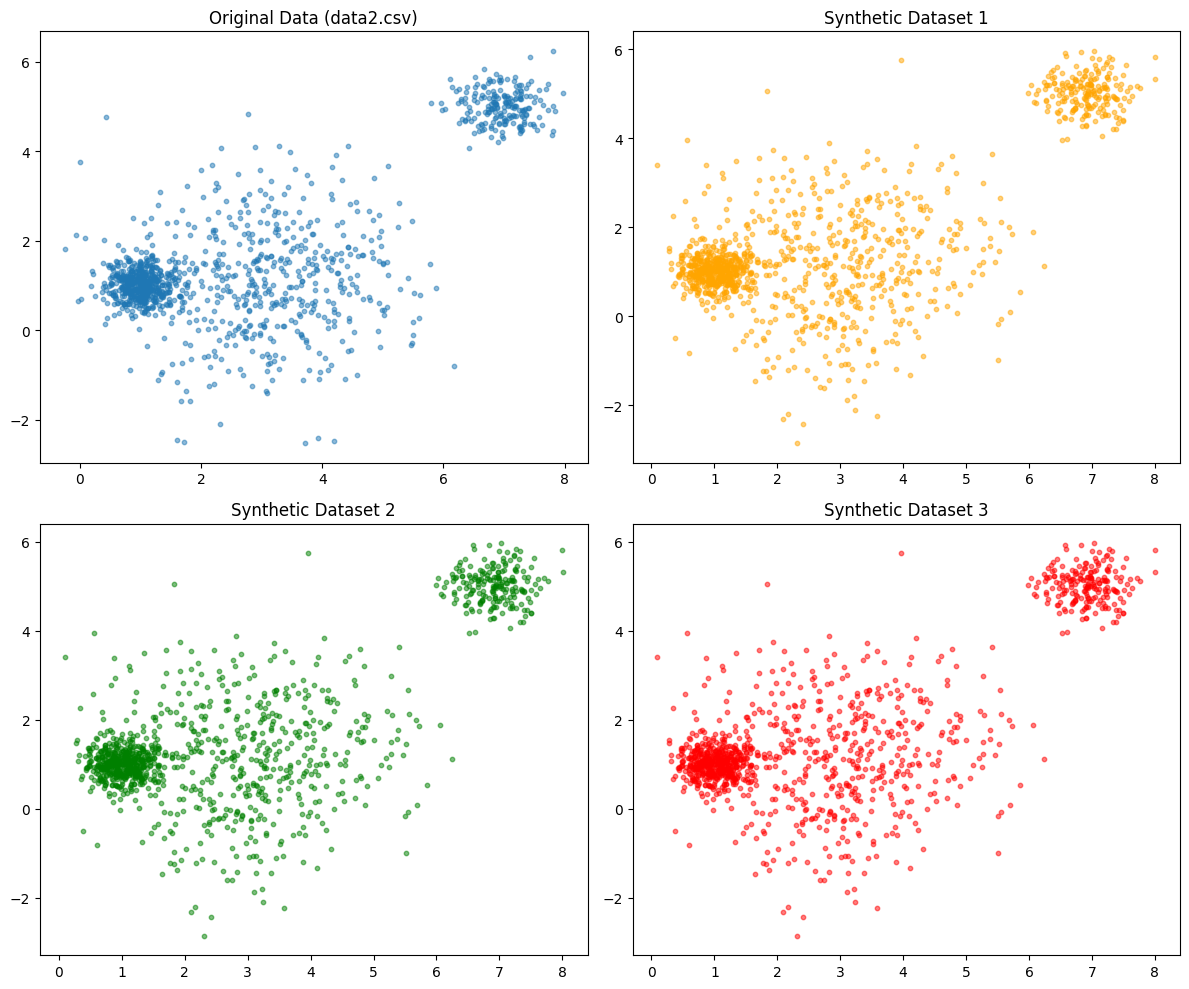

In [ ]:
# 1. Fit the GMM to your original data (using 5 components)
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
gmm.fit(data_2[["X1", "X2"]])

# 2. Get the number of points in the original dataset
N = len(data_2)

# 3. Simulate 3 synthetic datasets
# gmm.sample(N) returns [data, labels]
synthetic_1, _ = gmm.sample(N)
synthetic_2, _ = gmm.sample(N)
synthetic_3, _ = gmm.sample(N)

# 4. Create the 2x2 Plot Grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot Original Data
axes[0, 0].scatter(data_2["X1"], data_2["X2"], alpha=0.5, s=10)
axes[0, 0].set_title("Original Data (data2.csv)")

# Plot Synthetic Sets
axes[0, 1].scatter(synthetic_1[:, 0], synthetic_1[:, 1], alpha=0.5, s=10, color='orange')
axes[0, 1].set_title("Synthetic Dataset 1")

axes[1, 0].scatter(synthetic_2[:, 0], synthetic_2[:, 1], alpha=0.5, s=10, color='green')
axes[1, 0].set_title("Synthetic Dataset 2")

axes[1, 1].scatter(synthetic_3[:, 0], synthetic_3[:, 1], alpha=0.5, s=10, color='red')
axes[1, 1].set_title("Synthetic Dataset 3")

plt.tight_layout()
plt.show()